In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Set Plot Style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv('Housing.csv')

In [7]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [8]:
# stories = Number of floors in the house
# prefarea = Whether the house is located in a preferred (high-demand) residential area

In [9]:
df.shape

(545, 13)

In [10]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [12]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [13]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [14]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [15]:
df.describe(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

In [18]:
#Separate Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [19]:
numerical_cols.dtype

dtype('O')

In [20]:
categorical_cols.dtype

dtype('O')

In [21]:
df_clean = df.copy()

In [22]:
df_clean.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [23]:
df_clean = df_clean.drop_duplicates()

In [24]:
df_clean.shape

(545, 13)

In [25]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df_clean[col].value_counts())


mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64

basement
basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea
prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [26]:
for col in categorical_cols:
    df_clean[col] = df_clean[col].str.strip()

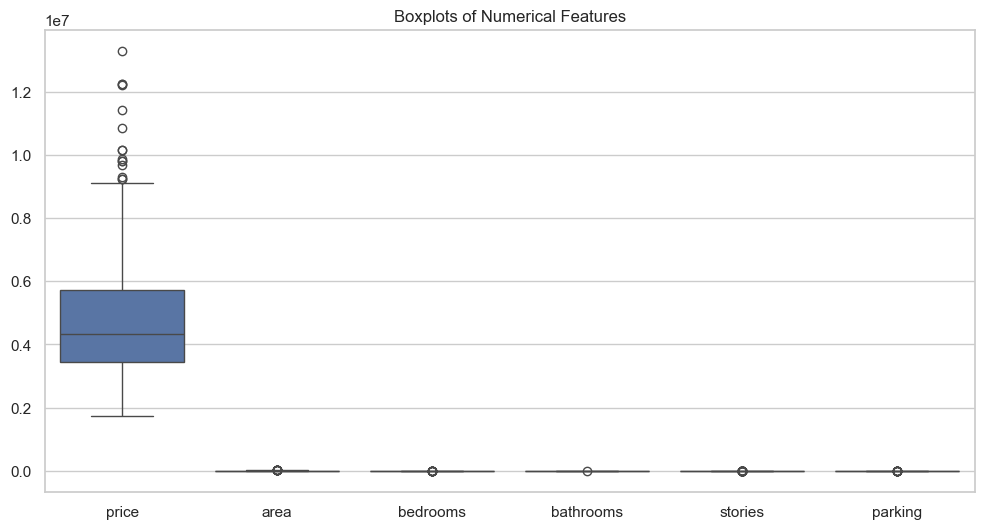

In [27]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean[numerical_cols])
plt.title("Boxplots of Numerical Features")
plt.show()

In [28]:
df_clean.to_csv("Housing_Cleaned.csv", index=False)

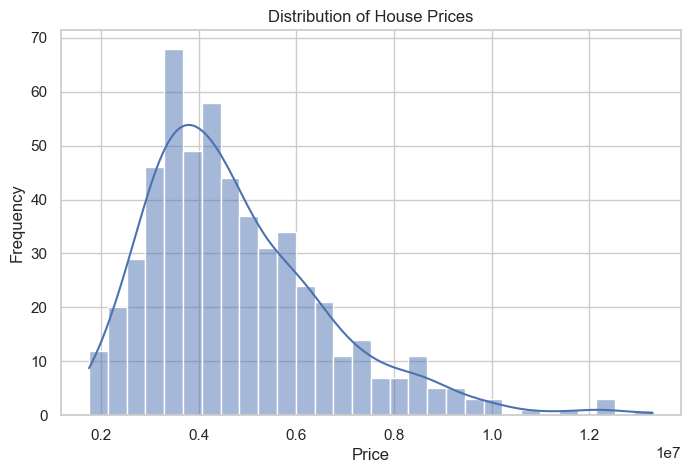

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean['price'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

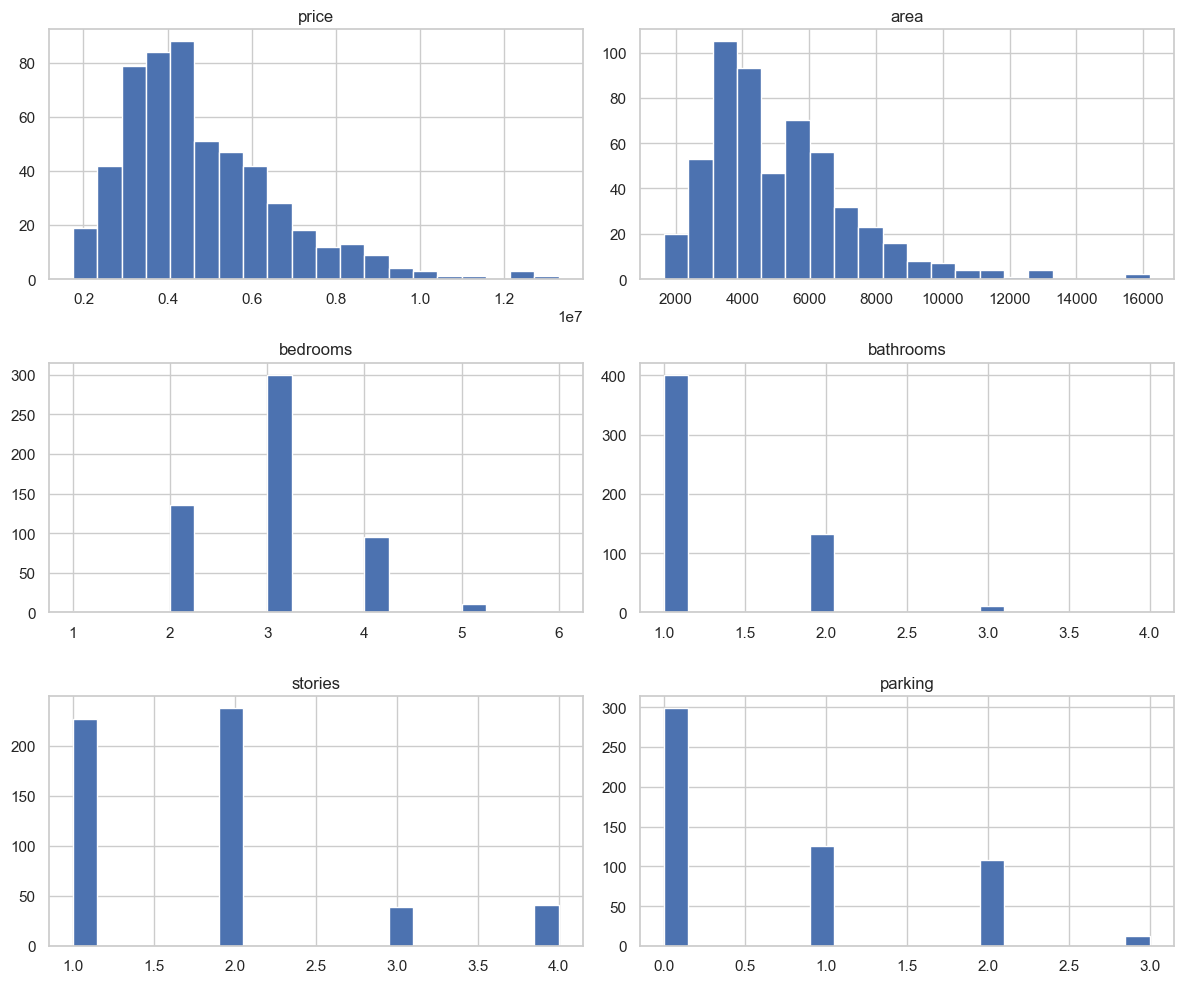

In [30]:
df_clean[numerical_cols].hist(
    figsize=(12,10),
    bins=20
)

plt.tight_layout()
plt.show()

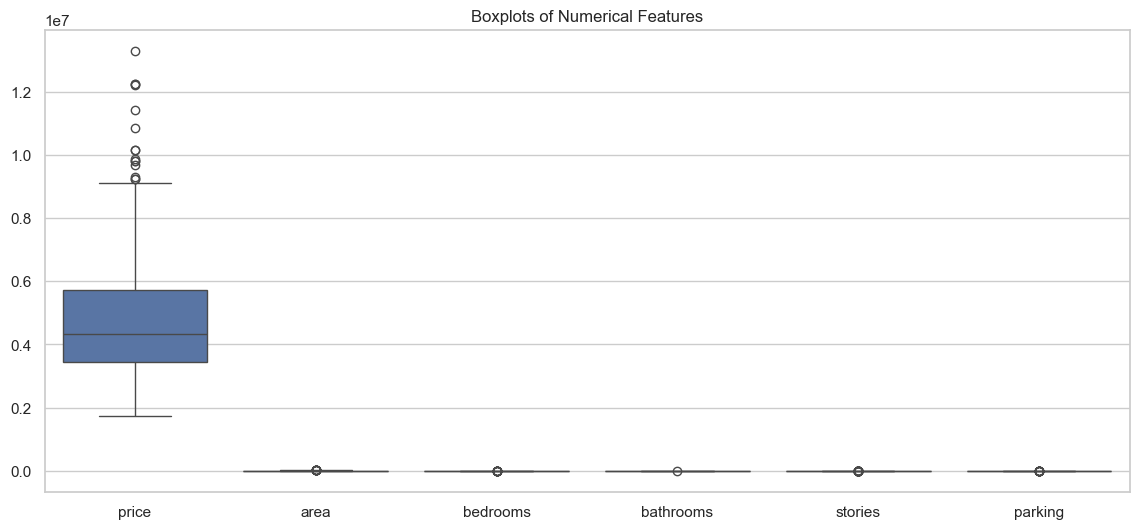

In [31]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df_clean[numerical_cols])
plt.title("Boxplots of Numerical Features")
plt.show()

In [32]:
corr = df_clean[numerical_cols].corr()
corr

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


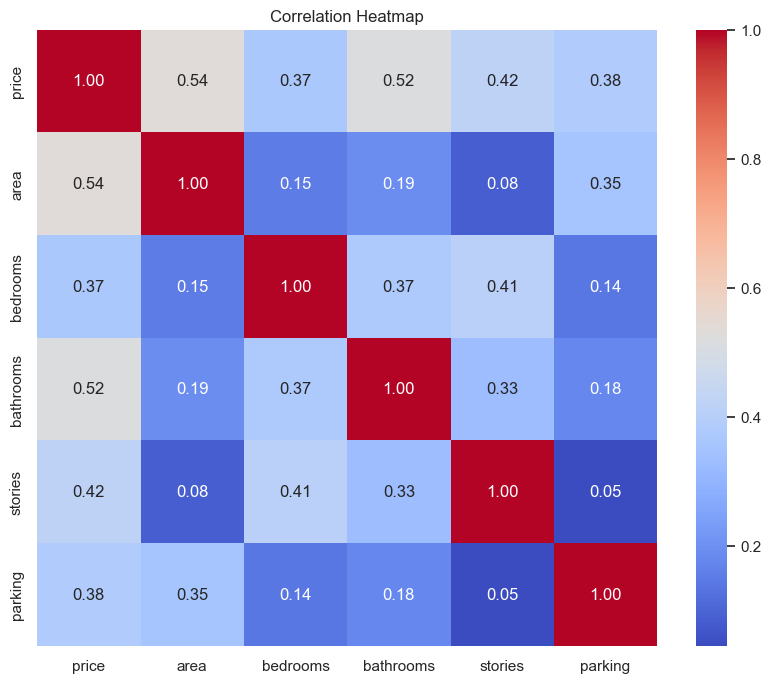

In [33]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

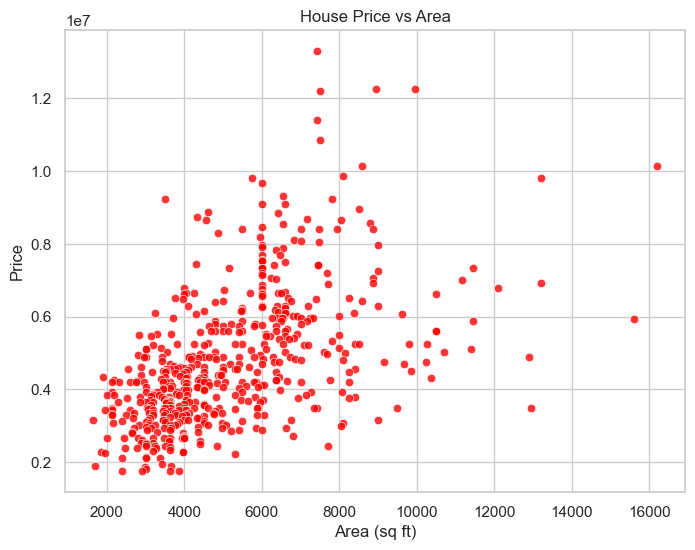

In [100]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x='area',
    y='price',
    alpha=0.8,
    color = "red"
)

plt.title("House Price vs Area")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")

plt.grid(True)

plt.show()

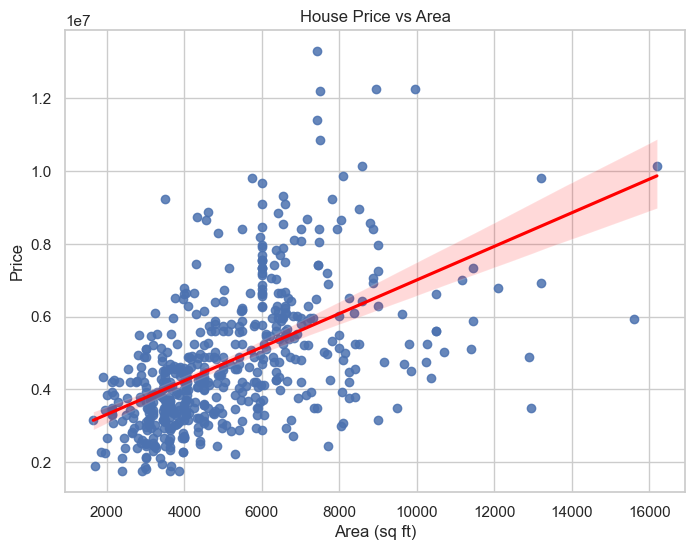

In [35]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_clean,
    x='area',
    y='price',
    scatter_kws={'alpha':0.85},
    line_kws={'color':'red'}
)

plt.title("House Price vs Area")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")

plt.show()

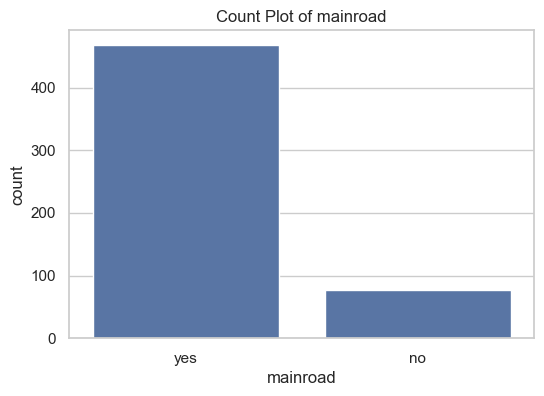

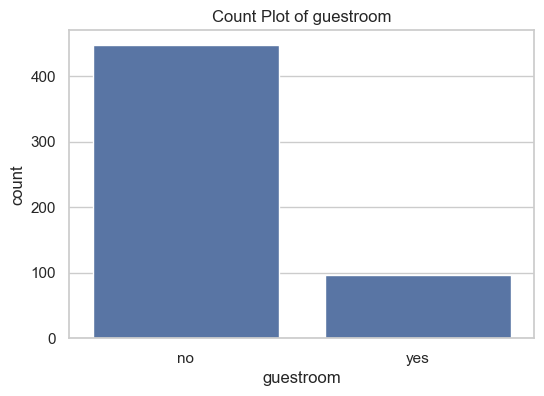

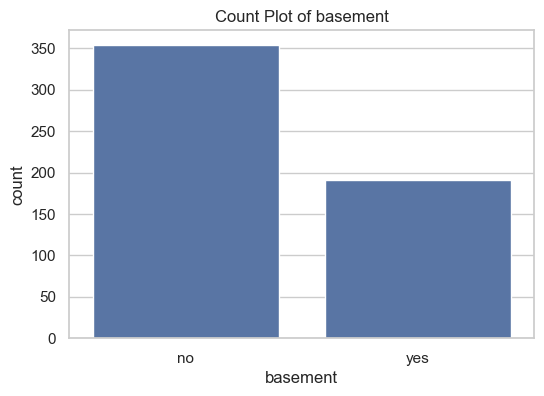

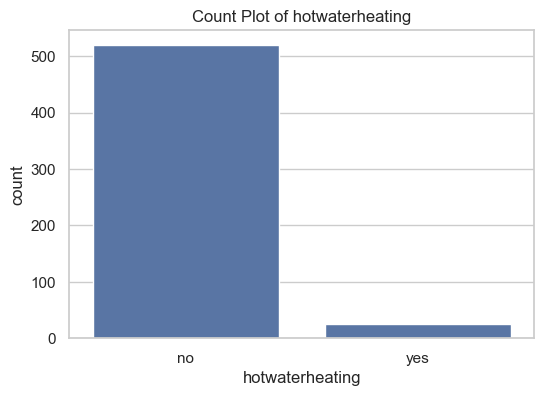

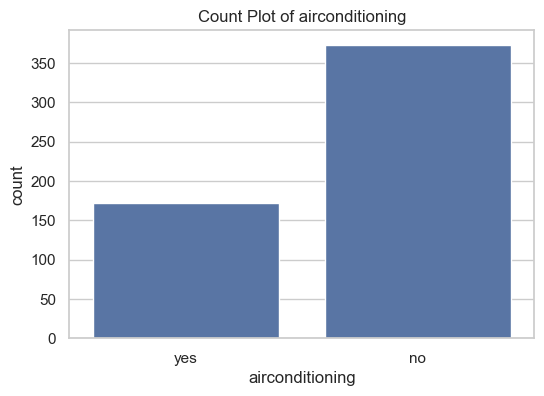

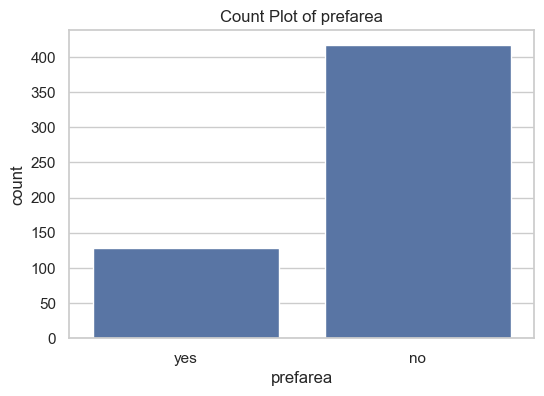

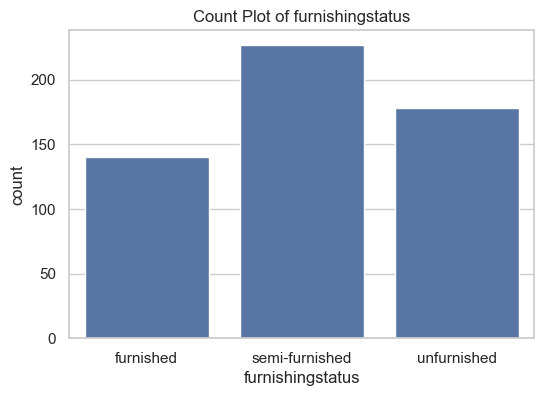

In [36]:
for col in categorical_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df_clean,
        x=col
    )

    plt.title(f"Count Plot of {col}")
    
plt.show()

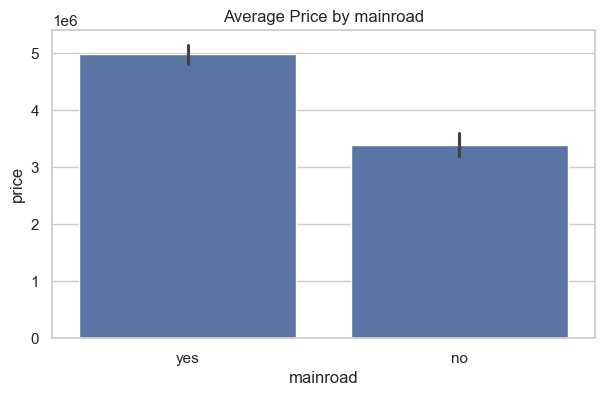

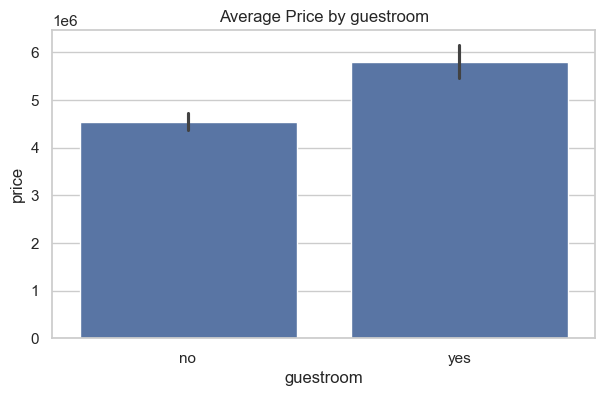

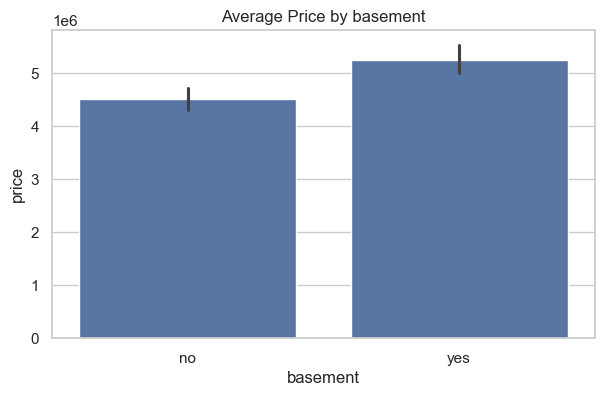

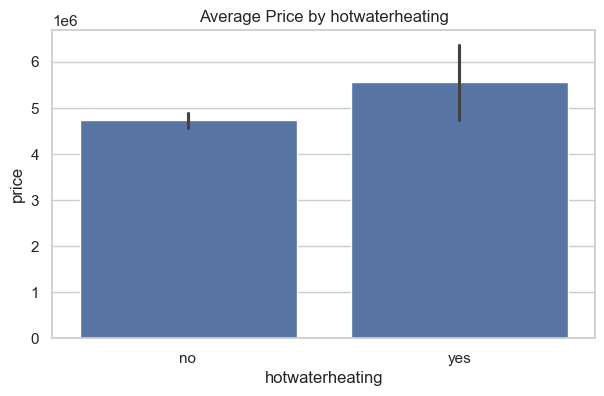

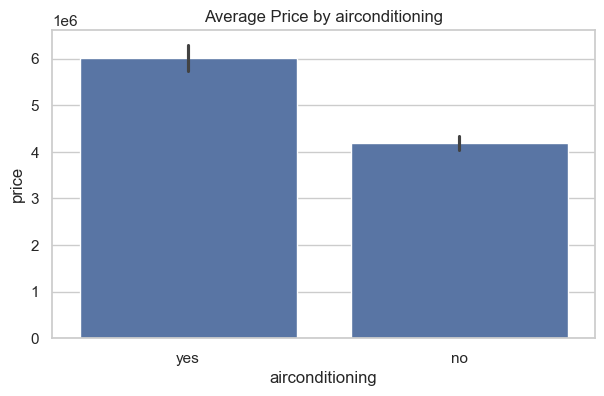

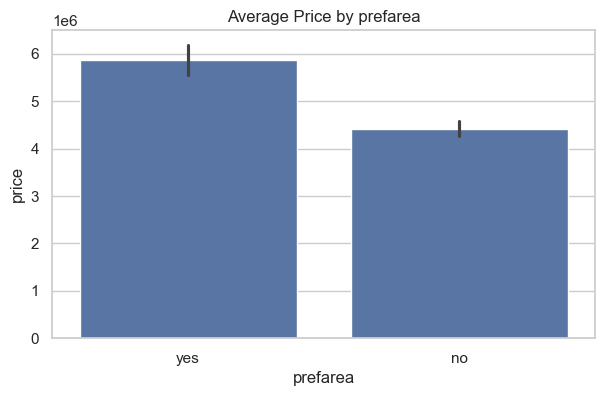

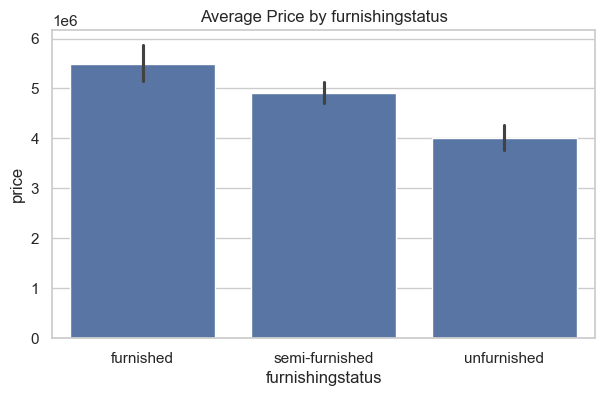

In [37]:
for col in categorical_cols:

    plt.figure(figsize=(7,4))

    sns.barplot(
        data=df_clean,
        x=col,
        y='price'
    )

    plt.title(f"Average Price by {col}")

    plt.show()

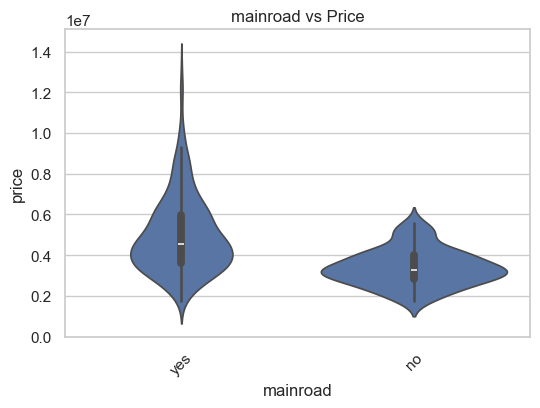

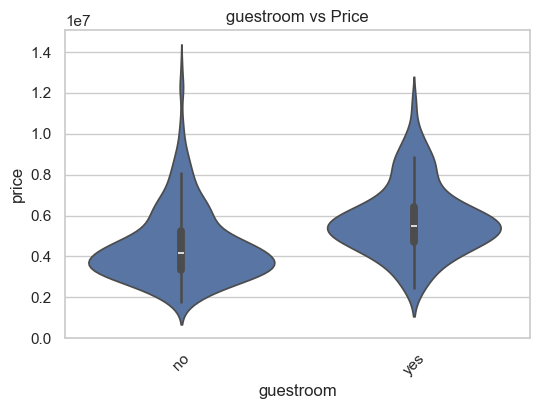

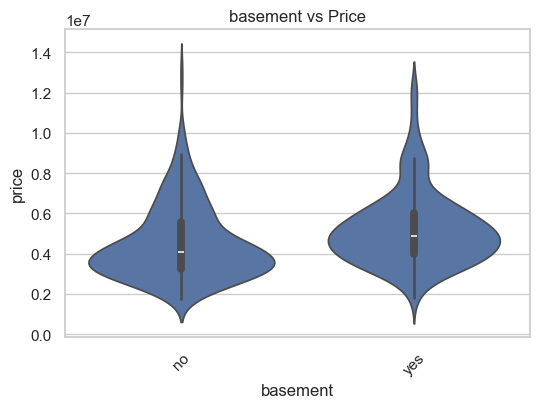

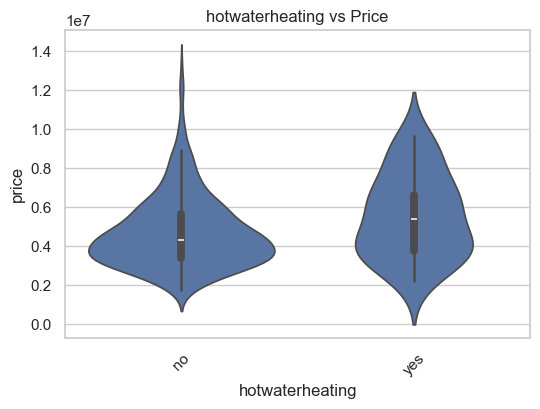

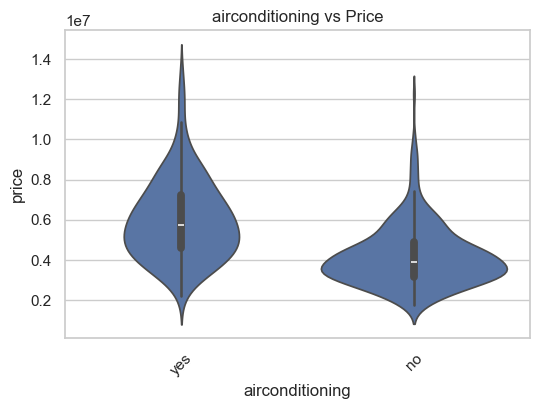

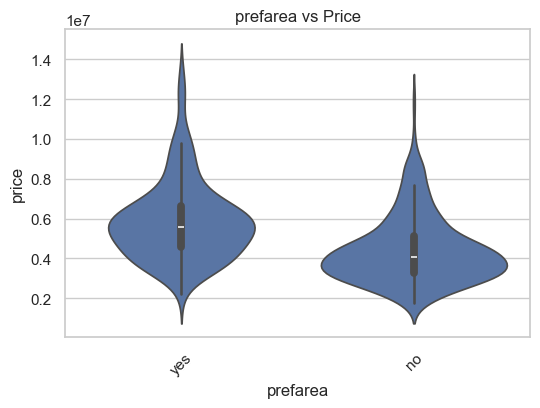

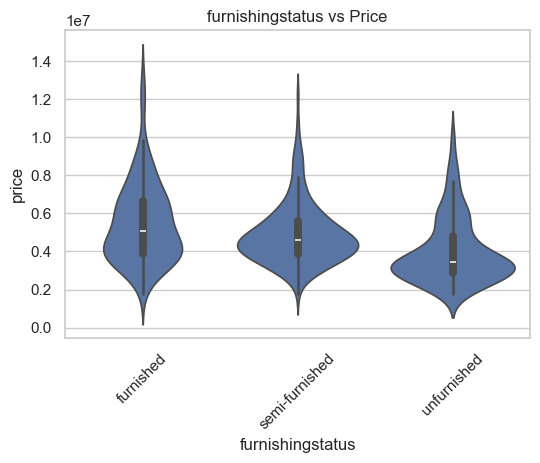

In [38]:
for col in categorical_cols:

    plt.figure(figsize=(6,4))

    sns.violinplot(
        data=df_clean,
        x=col,
        y='price'
    )

    plt.xticks(rotation=45)

    plt.title(f"{col} vs Price")

    plt.show()

In [39]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df_clean[col].unique())


mainroad
['yes' 'no']

guestroom
['no' 'yes']

basement
['no' 'yes']

hotwaterheating
['no' 'yes']

airconditioning
['yes' 'no']

prefarea
['yes' 'no']

furnishingstatus
['furnished' 'semi-furnished' 'unfurnished']


In [40]:
#Encode Binary Categorical Features
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df_clean[col] = df_clean[col].map({
        'yes':1,
        'no':0
    })

In [41]:
df_clean[binary_cols].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [42]:
df_clean['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [43]:
#Use One-Hot Encoding
df_clean = pd.get_dummies(
    df_clean,
    columns=['furnishingstatus'],
    drop_first=True,
    dtype=int
)

In [44]:
df_clean.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [45]:
df_clean.dtypes

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object

In [46]:
#Define Features (X) and Target (y)
X = df_clean.drop('price', axis=1)
y = df_clean['price']

In [47]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [48]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [49]:
X.shape

(545, 13)

In [50]:
y.shape

(545,)

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [52]:
X_train.shape

(436, 13)

In [53]:
X_test.shape

(109, 13)

In [54]:
y_train.shape

(436,)

In [55]:
y_test.shape

(109,)

In [56]:
X_train.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,6000,3,2,4,1,0,0,0,1,1,0,0,0
93,7200,3,2,1,1,0,1,0,1,3,0,1,0
335,3816,2,1,1,1,0,1,0,1,2,0,0,0
412,2610,3,1,2,1,0,1,0,0,0,1,0,1
471,3750,3,1,2,1,0,0,0,0,0,0,0,1


In [57]:
X_test.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,5900,4,2,2,0,0,1,0,0,1,0,0,1
77,6500,3,2,3,1,0,0,0,1,0,1,0,0
360,4040,2,1,1,1,0,0,0,0,0,0,1,0
90,5000,3,1,2,1,0,0,0,1,0,0,1,0
493,3960,3,1,1,1,0,0,0,0,0,0,0,0


In [58]:
y_train.head()

46     7525000
93     6300000
335    3920000
412    3430000
471    3010000
Name: price, dtype: int64

In [59]:
y_test.head()

316    4060000
77     6650000
360    3710000
90     6440000
493    2800000
Name: price, dtype: int64

In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
lr = LinearRegression()

In [62]:
# Train the Model
lr.fit(X_train, y_train)

LinearRegression()

In [63]:
Intercept = lr.intercept_

In [64]:
Intercept

np.float64(260032.35760741588)

In [65]:
Betas = lr.coef_

In [66]:
Betas

array([ 2.35968805e+02,  7.67787016e+04,  1.09444479e+06,  4.07476595e+05,
        3.67919948e+05,  2.31610037e+05,  3.90251176e+05,  6.84649885e+05,
        7.91426736e+05,  2.24841913e+05,  6.29890565e+05, -1.26881818e+05,
       -4.13645062e+05])

In [67]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_.astype(int)
})

coefficients

,Feature,Coefficient
0,area,235
1,bedrooms,76778
2,bathrooms,1094444
3,stories,407476
4,mainroad,367919
5,guestroom,231610
6,basement,390251
7,hotwaterheating,684649
8,airconditioning,791426
9,parking,224841


In [68]:
coefficients.sort_values(
    by='Coefficient',
    ascending=False
)
coefficients

,Feature,Coefficient
0,area,235
1,bedrooms,76778
2,bathrooms,1094444
3,stories,407476
4,mainroad,367919
5,guestroom,231610
6,basement,390251
7,hotwaterheating,684649
8,airconditioning,791426
9,parking,224841


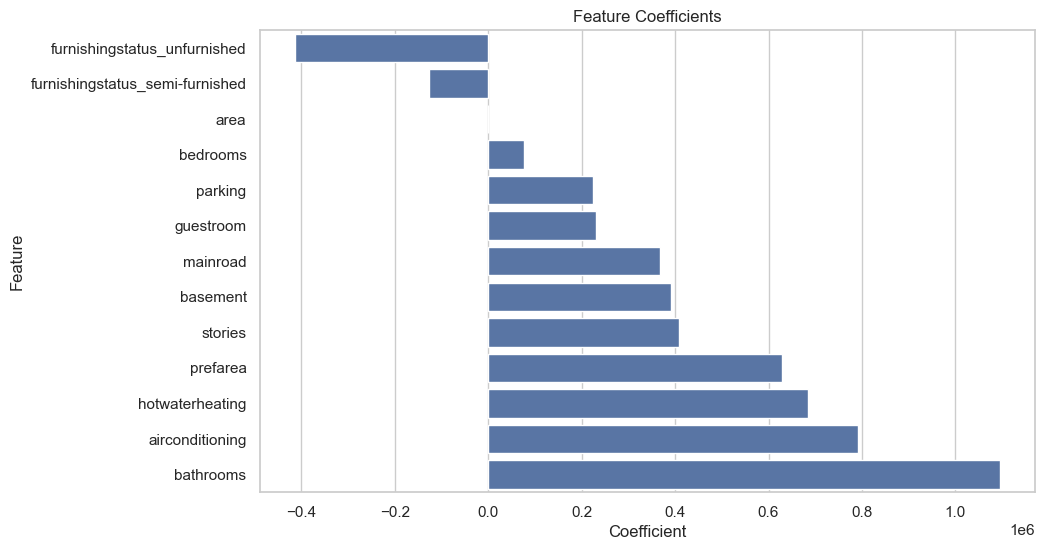

In [69]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coefficients.sort_values(by='Coefficient'),
    x='Coefficient',
    y='Feature'
)

plt.title("Feature Coefficients")

plt.show()

In [70]:
print(f"Intercept: {lr.intercept_:.2f}")

for feature, coef in zip(X_train.columns, lr.coef_):
    print(f"{feature}: {coef:.2f}")

Intercept: 260032.36
area: 235.97
bedrooms: 76778.70
bathrooms: 1094444.79
stories: 407476.59
mainroad: 367919.95
guestroom: 231610.04
basement: 390251.18
hotwaterheating: 684649.89
airconditioning: 791426.74
parking: 224841.91
prefarea: 629890.57
furnishingstatus_semi-furnished: -126881.82
furnishingstatus_unfurnished: -413645.06


In [71]:
y_pred = lr.predict(X_test)

In [72]:
y_pred

array([5164653.90033968, 7224722.29802167, 3109863.24240338,
       4612075.3272256 , 3294646.25725956, 3532275.09556559,
       5611774.56836476, 6368145.98732718, 2722856.95689986,
       2629405.61585782, 9617039.5031558 , 2798087.30447888,
       3171096.76847064, 3394639.09125528, 3681088.65424275,
       5263187.74621485, 3035963.47612384, 4786122.80040051,
       4349551.9200572 , 3572362.09930452, 5774875.21395649,
       5886993.57919884, 2730836.19518458, 4727316.47323635,
       5244847.52716801, 7555324.21605603, 3220790.84680268,
       5191898.79934206, 8143726.91009786, 3398814.09825035,
       6490693.05027925, 3315105.9074781 , 6708457.36761326,
       4201738.21071676, 3557571.06735186, 5836974.50478626,
       4808660.67448475, 4362878.73613261, 3191242.95701508,
       4596554.93225238, 4566042.86048411, 3517779.52374148,
       7205844.79365835, 3983597.27861103, 3749338.70271056,
       4274731.09125896, 6757442.10783741, 4037320.43665851,
       3769334.90397126,

In [73]:
y_test.shape

(109,)

In [74]:
y_pred.shape

(109,)

In [75]:
#Compare Actual and Predicted Prices
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred.astype(int)
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5164653
1,6650000,7224722
2,3710000,3109863
3,6440000,4612075
4,2800000,3294646
5,4900000,3532275
6,5250000,5611774
7,4543000,6368145
8,2450000,2722856
9,3353000,2629405


In [76]:
#Calculate Prediction Error
comparison["Error"] = comparison["Actual Price"] - comparison["Predicted Price"]
comparison.head()

,Actual Price,Predicted Price,Error
0,4060000,5164653,-1104653
1,6650000,7224722,-574722
2,3710000,3109863,600137
3,6440000,4612075,1827925
4,2800000,3294646,-494646


In [77]:
comparison["Absolute Error"] = comparison["Error"].abs()
comparison.head()

,Actual Price,Predicted Price,Error,Absolute Error
0,4060000,5164653,-1104653,1104653
1,6650000,7224722,-574722,574722
2,3710000,3109863,600137,600137
3,6440000,4612075,1827925,1827925
4,2800000,3294646,-494646,494646


In [78]:
new_house = pd.DataFrame({
    'area': [5000],
    'bedrooms': [3],
    'bathrooms': [2],
    'stories': [2],
    'mainroad': [1],
    'guestroom': [0],
    'basement': [1],
    'hotwaterheating': [0],
    'airconditioning': [1],
    'parking': [2],
    'prefarea': [1],
    'furnishingstatus_semi-furnished': [1],
    'furnishingstatus_unfurnished': [0]
})

In [79]:
predicted_price = lr.predict(new_house)
print(f"Predicted House Price: ₹{predicted_price}")

Predicted House Price: ₹[7176345.6813739]


In [80]:
#Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [81]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:,.2f}")

Mean Absolute Error (MAE): 970,043.40


In [82]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:,.2f}")

Mean Squared Error (MSE): 1,754,318,687,330.66


In [83]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")

Root Mean Squared Error (RMSE): 1,324,506.96


In [84]:
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.6529


In [85]:
#Adjusted R²
n = X_test.shape[0]       # Number of test samples
p = X_test.shape[1]       # Number of features

adjusted_r2 = 1 - ((1-r2)*(n-1))/(n-p-1)
print(f"Adjusted R²: {adjusted_r2:.4f}")

Adjusted R²: 0.6054


In [86]:
print(f"MAE           : {mae:,.2f}")

print(f"MSE           : {mse:,.2f}")

print(f"RMSE          : {rmse:,.2f}")

print(f"R² Score      : {r2:.4f}")

print(f"Adjusted R²   : {adjusted_r2:.4f}")

MAE           : 970,043.40
MSE           : 1,754,318,687,330.66
RMSE          : 1,324,506.96
R² Score      : 0.6529
Adjusted R²   : 0.6054


In [87]:
residuals = y_test - y_pred

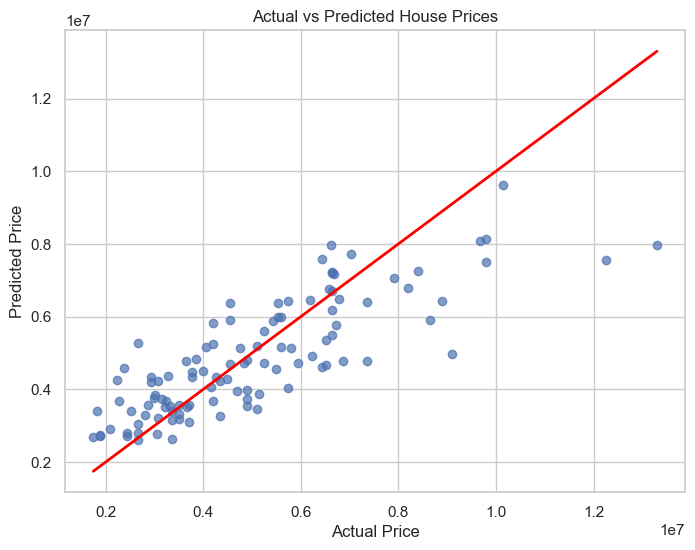

In [88]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

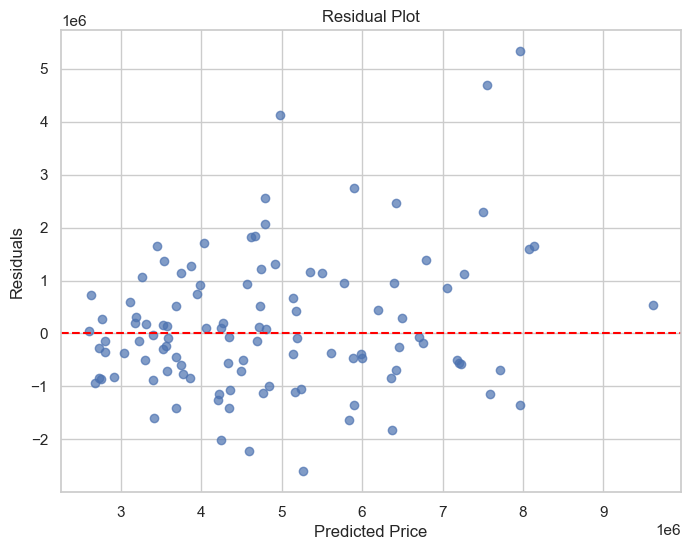

In [89]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

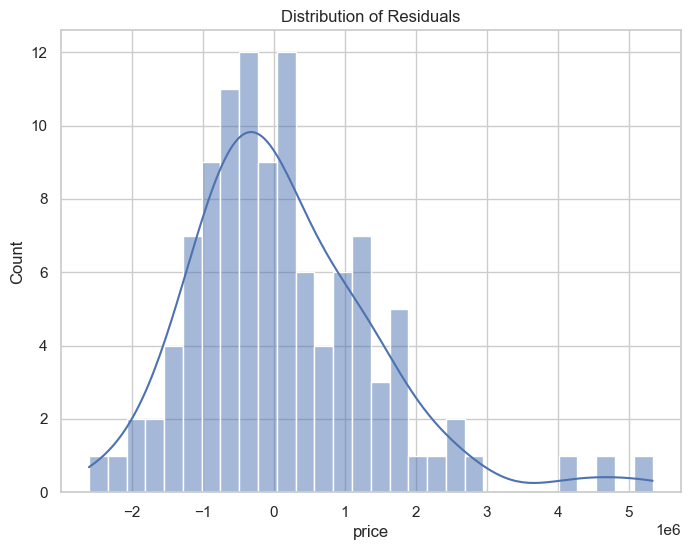

In [90]:
plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Distribution of Residuals")

plt.show()

In [91]:
import scipy.stats as stats

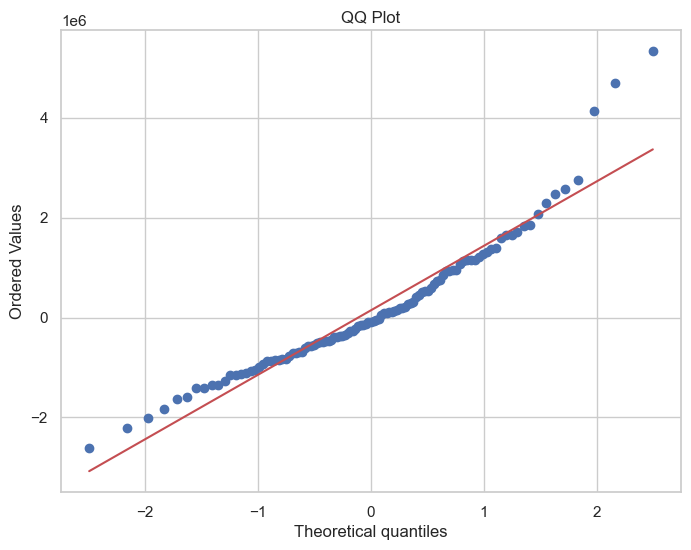

In [92]:
plt.figure(figsize=(8,6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("QQ Plot")

plt.show()

In [199]:
print("Mean of Residuals:", residuals.mean())

Mean of Residuals: 146055.36163152126


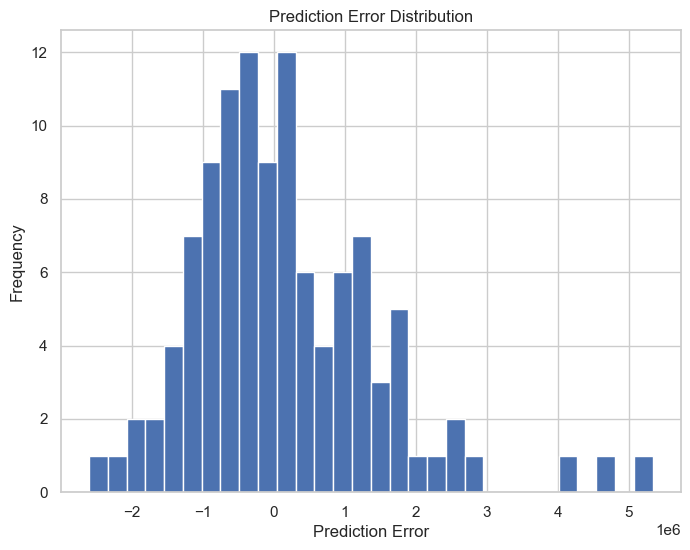

In [205]:
errors = y_test - y_pred

plt.figure(figsize=(8,6))

plt.hist(
    errors,
    bins=30
)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

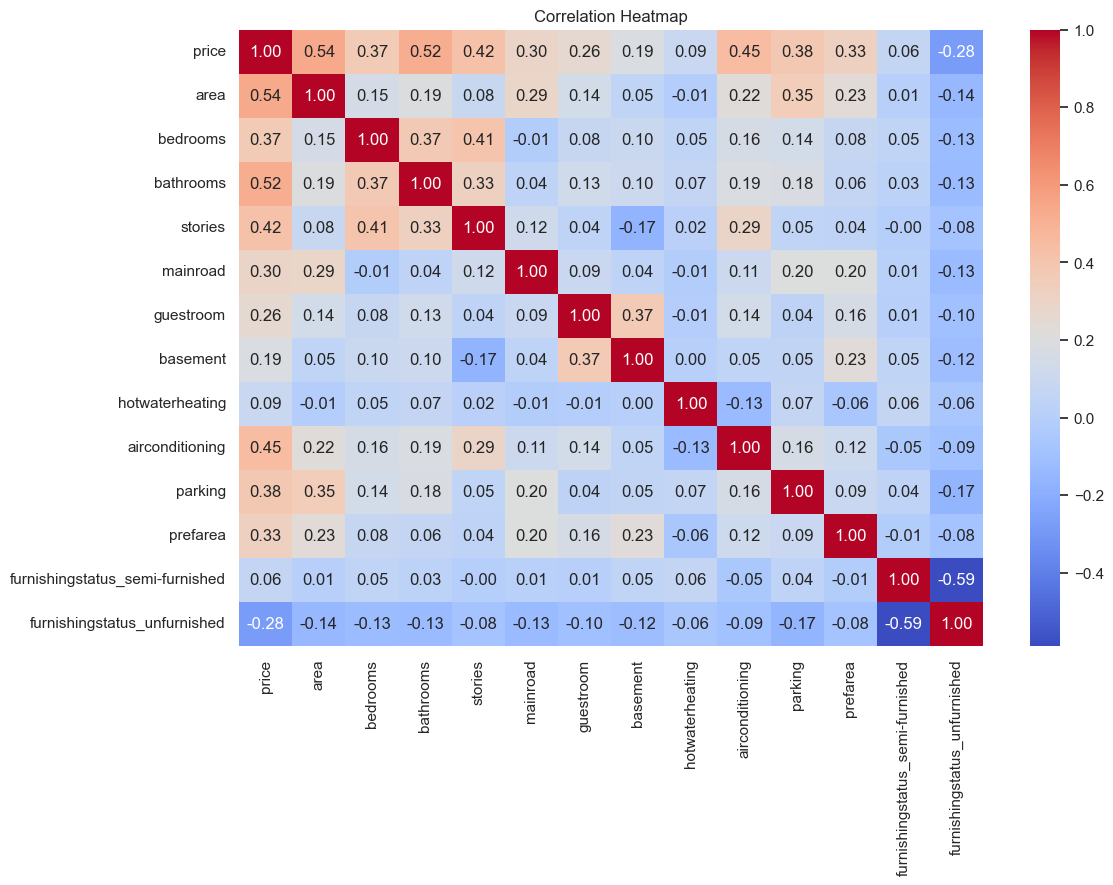

In [206]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [93]:
area_range = np.linspace(
    df_clean['area'].min(),
    df_clean['area'].max(),
    50
)

bathroom_range = np.linspace(
    df_clean['bathrooms'].min(),
    df_clean['bathrooms'].max(),
    50
)

area_grid, bathroom_grid = np.meshgrid(area_range, bathroom_range)

In [94]:
grid = pd.DataFrame()

# Features to vary
grid['area'] = area_grid.ravel()
grid['bathrooms'] = bathroom_grid.ravel()

# Numerical features kept constant (mean)
grid['bedrooms'] = df_clean['bedrooms'].mean()
grid['stories'] = df_clean['stories'].mean()
grid['parking'] = df_clean['parking'].mean()

# Binary features kept constant (mode)
grid['mainroad'] = df_clean['mainroad'].mode()[0]
grid['guestroom'] = df_clean['guestroom'].mode()[0]
grid['basement'] = df_clean['basement'].mode()[0]
grid['hotwaterheating'] = df_clean['hotwaterheating'].mode()[0]
grid['airconditioning'] = df_clean['airconditioning'].mode()[0]
grid['prefarea'] = df_clean['prefarea'].mode()[0]

# One-Hot Encoded columns
grid['furnishingstatus_semi-furnished'] = 0
grid['furnishingstatus_unfurnished'] = 0

In [95]:
grid = grid[X_train.columns]

In [96]:
price_grid = lr.predict(grid)

price_grid = price_grid.reshape(area_grid.shape)

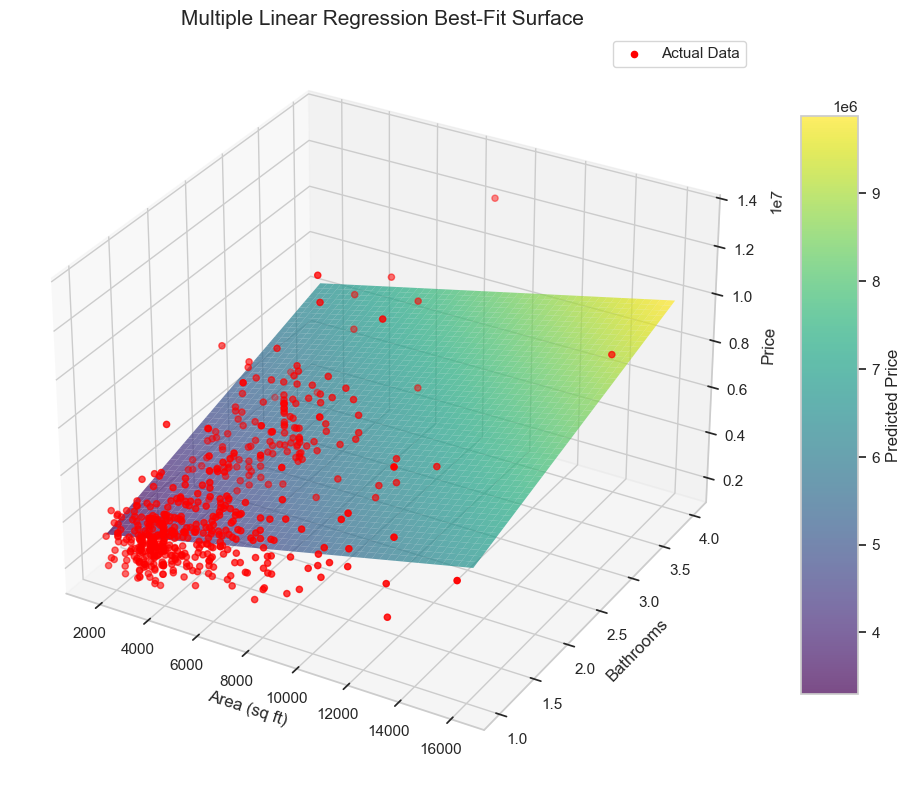

In [98]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,15))

ax = fig.add_subplot(111, projection='3d')

# Regression Surface
surface = ax.plot_surface(
    area_grid,
    bathroom_grid,
    price_grid,
    cmap='viridis',
    alpha=0.7,
    edgecolor='none'
)

# Actual Data Points
ax.scatter(
    df_clean['area'],
    df_clean['bathrooms'],
    df_clean['price'],
    color='red',
    s=20,
    label='Actual Data'
)

ax.set_xlabel("Area (sq ft)", fontsize=12)
ax.set_ylabel("Bathrooms", fontsize=12)
ax.set_zlabel("Price", fontsize=12)

ax.set_title("Multiple Linear Regression Best-Fit Surface", fontsize=15)

fig.colorbar(surface, shrink=0.5, aspect=10, label="Predicted Price")

plt.legend()

plt.show()